# Quantum Optics - Homework 2 - Damping the oscillations

## Jan Chelmecki

In [1]:
import numpy as np
import matplotlib.pyplot as plt

A characteristic of a squuezed state is the periodic oscillation of the width of the momentum wavefunction - as an elliptically shaped Wigner function rotates, its projection onto the $p$ axis oscillates in time, according to the analitical formula.

$$
\Delta p^2 = \frac{1}{2} \Big[ 
1 + \frac{(\omega \tau_1)^2}{2}
 − \omega \tau_1
\sqrt{
1 + \frac{(\omega \tau_1)^2}{4}} 
\cos(2 \omega \tau_2 − \phi) 
\Big]
\qquad 
\text{where} 
\qquad
\phi = \tan^{−1} \Big( \frac{2}{\omega \tau_1} \Big)
$$

This describes a perfect oscillation. Let's plot it.

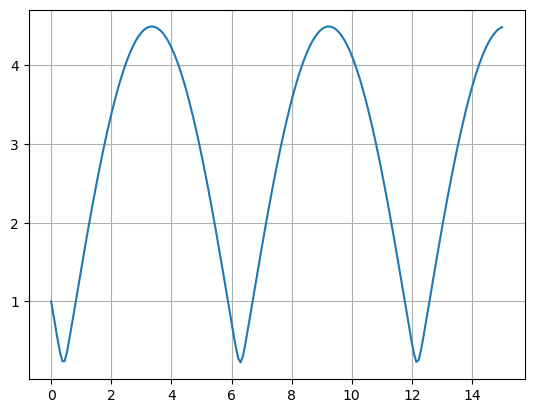

In [2]:
tau1 = 8.0
omega = 0.085*2*np.pi
phi = np.arctan( 2/(omega*tau1) )

tau2 = np.linspace(0,15,201)

dp2 = 1/2* (1 + (omega*tau1)**2/2 - (omega*tau1)* np.sqrt(1+(omega*tau1)**2 /4) * np.cos(2*omega*tau2 - phi))

plt.plot(tau2, np.sqrt(dp2/dp2[0]))
plt.grid()

However, what was measured in the experiment was the superposed signal from different potential wells with slightly diffent oscillator frequencies. As a result, the different $\Delta p^2$ oscillations have different frequencies, and so, as time elapses, they will slowly detune, and the overall mplitude will decrease. We'll model the $\omega$ distribution with a Gaussian.

Let's try
$$
\Delta p^2 = \int g(\omega) \cdot \Delta p^2_{\omega} \; d\omega 
$$
with
$$
g(\omega) = \frac{1}{\Delta \omega \sqrt{2\pi }} \exp\Big(-\frac{(\omega-\omega_0)^2}{2(\Delta \omega)^2}\Big)
$$

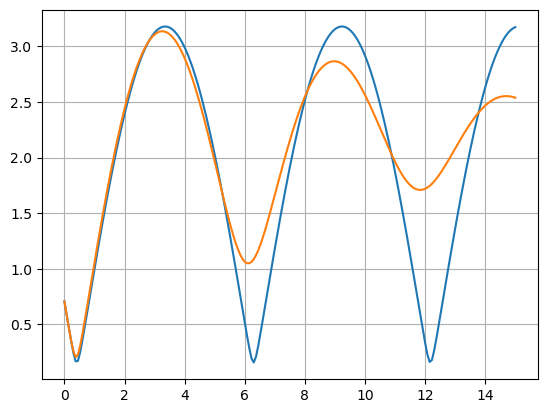

In [3]:
def g(omega, omega0, domega):
    return np.exp(- (omega-omega0)**2/2/domega**2)
"""
def g(omega, omega0, domega):
    if abs(omega-omega0)<domega :
        return 1/(2*domega)
    else:
        return 0
"""

omega0 = 0.085*2*np.pi
domega = 0.1*omega0
omegas = np.linspace(omega0-domega*4, omega0+domega*4, 201)

dp2_mat = np.zeros((tau2.size, omegas.size))
for i in range(len(omegas)):
    omega = omegas[i]
    phi = np.arctan( 2/(omegas[i]*tau1) )
    dp2_mat[:,i] = 1/2* (1 + (omega*tau1)**2/2 - (omega*tau1)* np.sqrt(1+(omega*tau1)**2 /4) * np.cos(2*omega*tau2 - phi)) * g(omega, omega0, domega)
#end

#integrate over omega
dp2_damped = ( np.sum(dp2_mat, 1) - 0.5*(dp2_mat[:,0]+dp2_mat[:,-1]) ) * (omegas[1]-omegas[0]) / (domega*np.sqrt(2*np.pi))
plt.plot(tau2, np.sqrt(dp2))
plt.plot(tau2, np.sqrt(dp2_damped))
plt.grid()

Sadly, this is mathec the figure in the article only quantitatively.